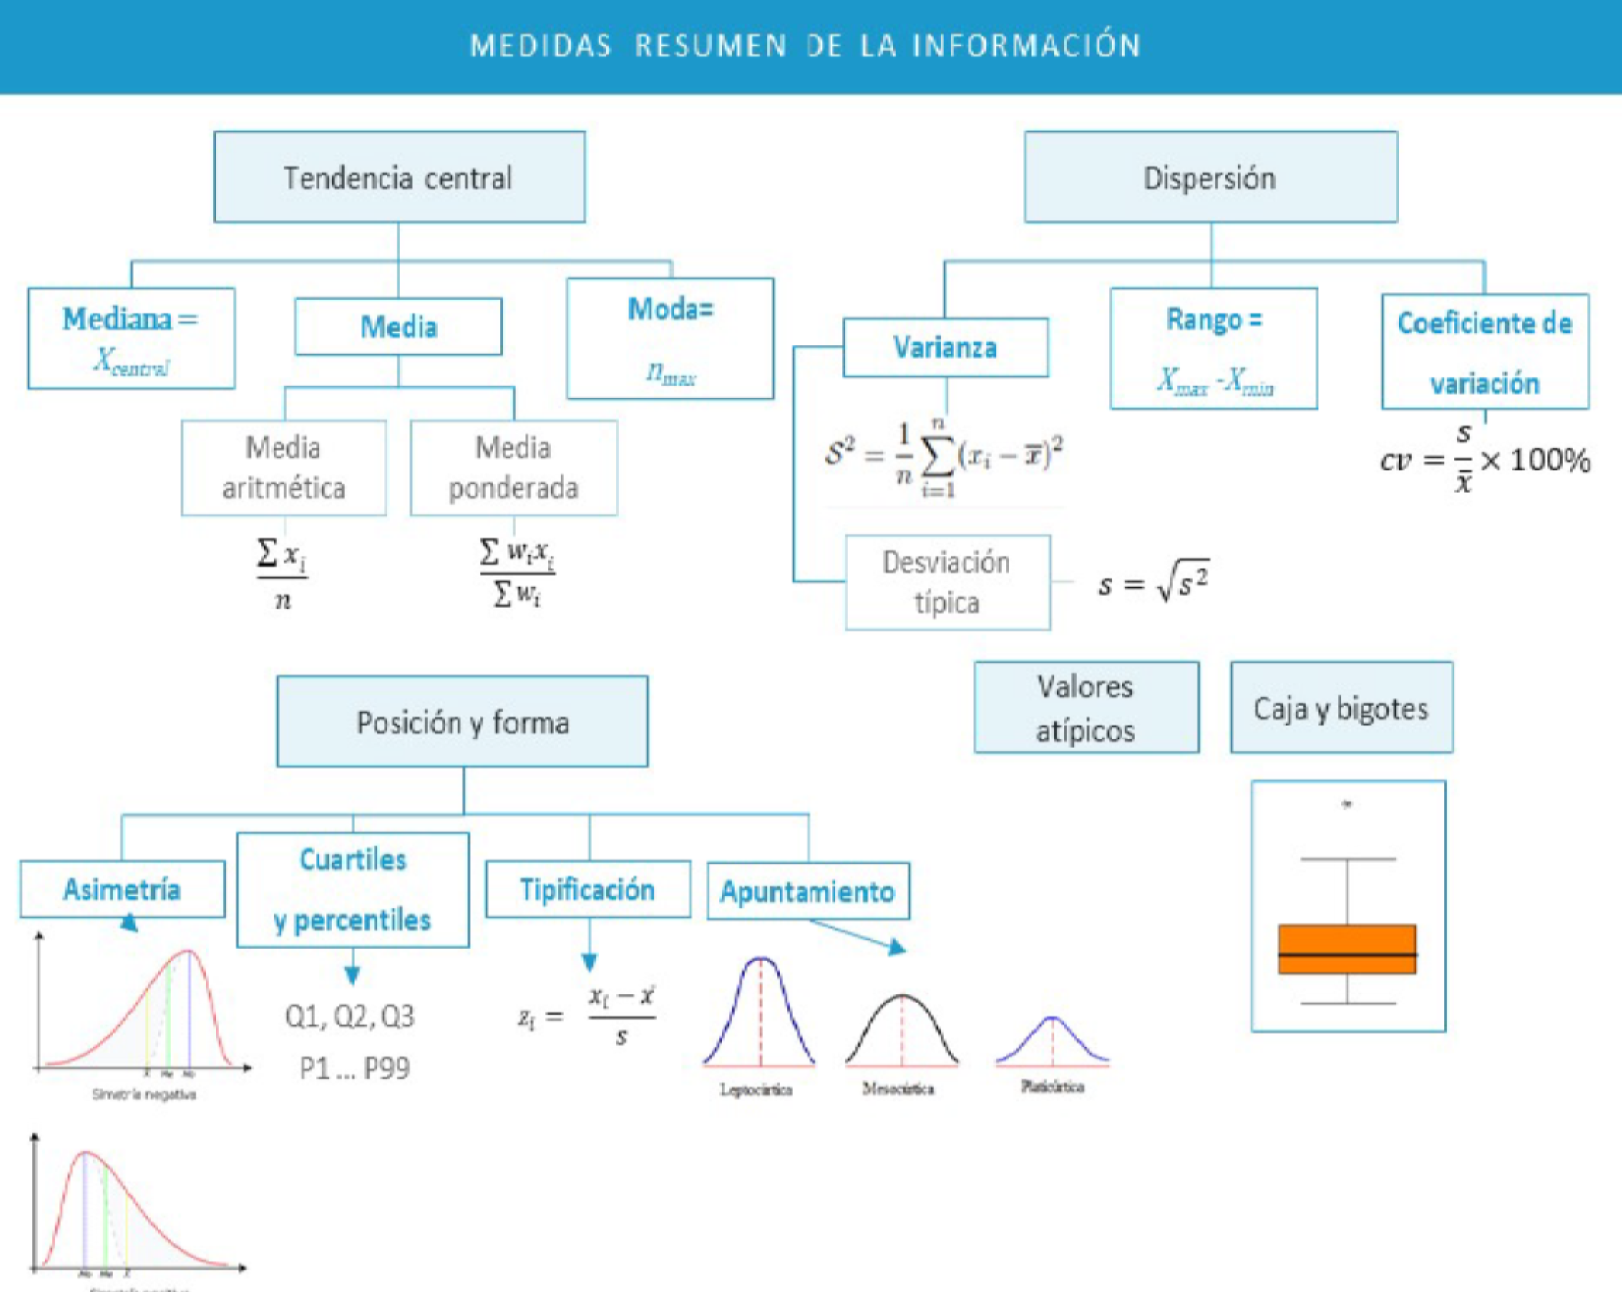

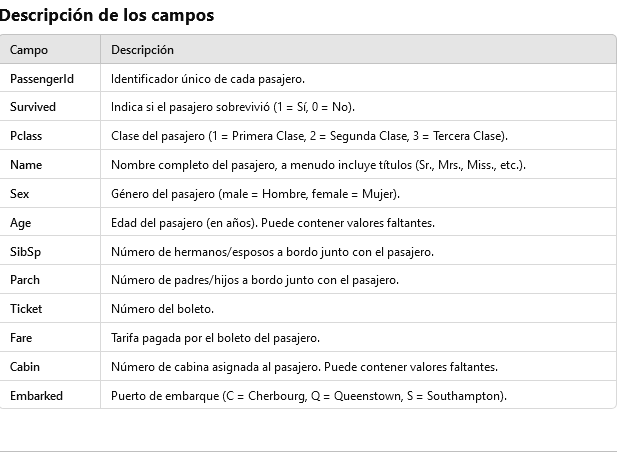

In [1]:
import pandas as pd
#import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis

# Configuración de gráficos
sns.set(style="whitegrid")

# Cargar el dataset
data = pd.read_csv("titanic.csv")




A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "C:\ProgramData\Anaconda3\lib\runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\ProgramData\Anaconda3\lib\runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py", line 16, in <module>
    app.launch_new_instance()
  File "C:\ProgramData\Anaconda3\lib\site-packages\traitlets\config\application.py", line 846, in launch_instance
    app.start()
  File "C:\ProgramData\Anaconda3\lib\site-pack

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "C:\ProgramData\Anaconda3\lib\runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\ProgramData\Anaconda3\lib\runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py", line 16, in <module>
    app.launch_new_instance()
  File "C:\ProgramData\Anaconda3\lib\site-packages\traitlets\config\application.py", line 846, in launch_instance
    app.start()
  File "C:\ProgramData\Anaconda3\lib\site-pack

AttributeError: _ARRAY_API not found

In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [3]:
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Medidas de tendencia central

##### La media indica el promedio de los datos. 
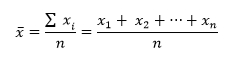

##### La media ponderada:
Es una medida de tendencia central en la que cada valor tiene un peso que refleja su importancia relativa. La fórmula de la media ponderada es:
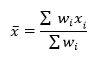

##### La media armónica:
Es una medida de tendencia central que se usa principalmente cuando los datos están en términos de tasas o proporciones. La fórmula es:

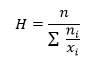

Donde:

    n: Número de observaciones.
    xi: Valores de los datos (deben ser mayores que cero).
    
**En el dataset del Titanic**, supongamos que queremos calcular la media ponderada de las tarifas pagadas (Fare) por los pasajeros, ponderadas por el número de acompañantes incluidos en el boleto (SibSp + Parch + 1, considerando al propio pasajero).


Media aritmética de las tarifas: 32.76
Media ponderada de las tarifas: 41.70
Media armónica de las tarifas: 13.68


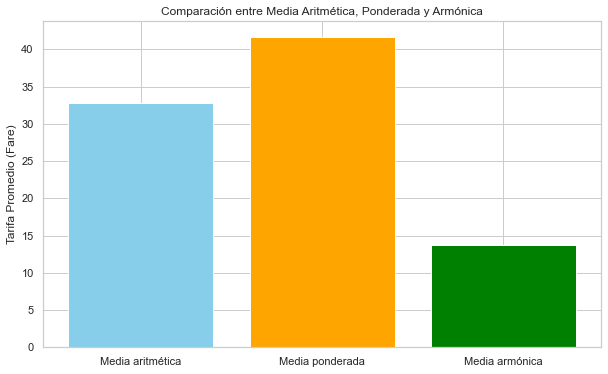

In [5]:
from scipy.stats import hmean  # Para calcular la media armónica
# Crear la columna de pesos: número de personas por boleto
data['Weight'] = data['SibSp'] + data['Parch'] + 1  # Acompañantes más el pasajero

# Eliminar valores faltantes y tarifas iguales a cero (la media armónica no admite ceros)
data = data.dropna(subset=['Fare', 'Weight'])
data = data[data['Fare'] > 0]

# Calcular la media aritmética, ponderada y armónica
media_aritmetica = data['Fare'].mean()
media_ponderada = (data['Fare'] * data['Weight']).sum() / data['Weight'].sum()
media_armonica = hmean(data['Fare'])

# Resultados
print(f"Media aritmética de las tarifas: {media_aritmetica:.2f}")
print(f"Media ponderada de las tarifas: {media_ponderada:.2f}")
print(f"Media armónica de las tarifas: {media_armonica:.2f}")

# Comparar gráficamente

plt.figure(figsize=(10, 6))
plt.bar(['Media aritmética', 'Media ponderada', 'Media armónica'], 
        [media_aritmetica, media_ponderada, media_armonica], color=['skyblue', 'orange', 'green'])
plt.title('Comparación entre Media Aritmética, Ponderada y Armónica')
plt.ylabel('Tarifa Promedio (Fare)')
plt.show()


Peso de cada pasajero:
Se calcula considerando el número de acompañantes en el boleto (SibSp: hermanos/esposos, Parch: padres/hijos) más el pasajero mismo.

**Cálculo de la media ponderada:**

    Multiplicamos las tarifas (Fare) por el peso asociado (Weight).
    Sumamos los productos y dividimos por la suma de los pesos.

**Eliminar valores faltantes:**
Nos aseguramos de que las columnas relevantes (Fare y Weight) no contengan valores nulos.

**Media aritmética:** Se calcula con el método .mean(), considerando todas las tarifas sin tener en cuenta los pesos.

**Media ponderada:** Se calcula considerando los pesos como el número de personas asociadas al boleto (Weight).

**Comparación gráfica:** Creamos un gráfico de barras para comparar visualmente las dos medidas. Se genera una comparación visual entre ambas medidas, mostrando que la media ponderada es mayor debido a la mayor influencia de las tarifas altas con más acompañantes.
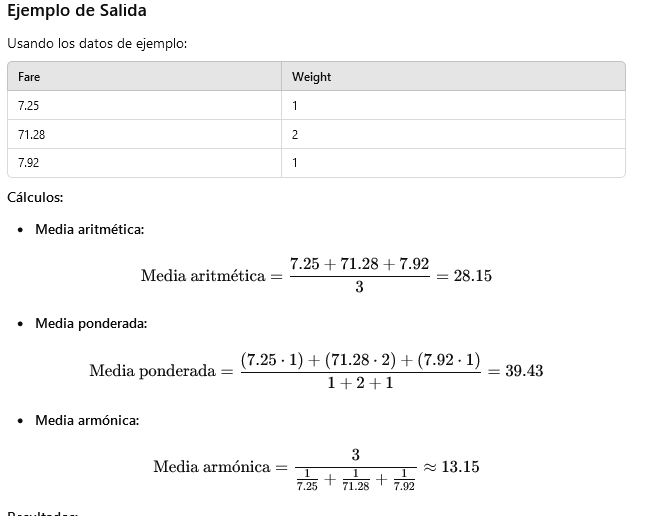

**La mediana**:
Una medida de tendencia central que es más robusta que la media frente a valores extremos es la mediana, observación que ocupa el lugar central en un conjunto dedatos. 

Al ocupar esta posición se nos presentan dos casos:

1.Cuando hay un número impar de observaciones la mediana ocupa justo el valor central.

2.Cuando el número de observaciones es par no existe posición central por lo que la mediana será el promedio entre las dos observaciones centrales.


--- 1. Medidas de Tendencia Central ---

Variable: Age
Media: 29.65, Mediana: 28.0, Moda: 24.0


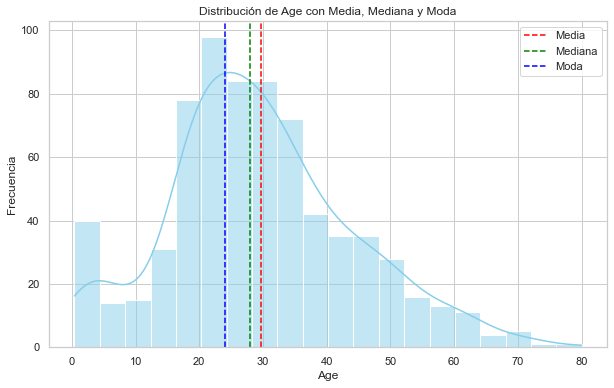


Variable: Fare
Media: 32.76, Mediana: 14.5, Moda: 8.05


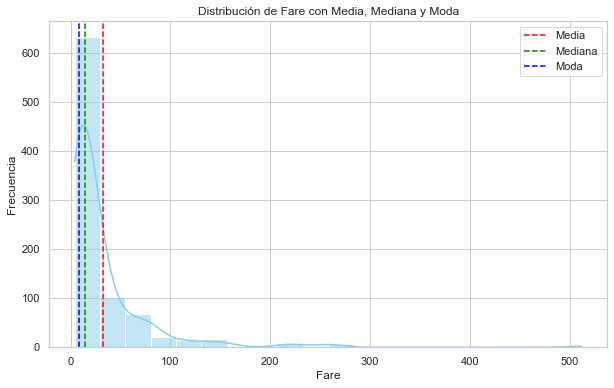

In [6]:
# --- 1. Medidas de Tendencia Central ---
print("\n--- 1. Medidas de Tendencia Central ---")
variables = ['Age', 'Fare']
for var in variables:
    print(f"\nVariable: {var}")
    mean_val = data[var].mean()#promedio o media 
    median_val = data[var].median()#mediana
    mode_val = data[var].mode()[0]#moda
    print(f"Media: {mean_val:.2f}, Mediana: {median_val}, Moda: {mode_val}")

    # Visualización
    plt.figure(figsize=(10, 6))
    sns.histplot(data[var].dropna(), kde=True, bins=20, color='skyblue')
    plt.axvline(mean_val, color='red', linestyle='--', label='Media')
    plt.axvline(median_val, color='green', linestyle='--', label='Mediana')
    plt.axvline(mode_val, color='blue', linestyle='--', label='Moda')
    plt.legend()
    plt.title(f"Distribución de {var} con Media, Mediana y Moda")
    plt.xlabel(var)
    plt.ylabel("Frecuencia")
    plt.show()


**Cálculo de la mediana para variables categóricas y segmentadas**

Supongamos que queremos calcular la mediana de la clase de pasajeros (Pclass) segmentada por la supervivencia (Survived).

Cálculo de la mediana general: Usamos .median() sobre la columna Pclass.
Mediana segmentada: Agrupamos los datos por Survived y calculamos la mediana para cada grupo con .groupby() y .median().
Visualización: Creamos un gráfico de barras para comparar las medianas entre los pasajeros que sobrevivieron y los que no.

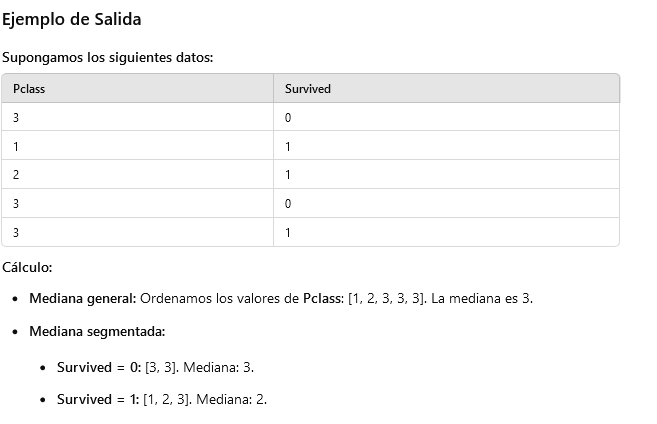

Mediana general de Pclass: 3.0
Mediana de Pclass segmentada por Survived:
Survived
0    3.0
1    2.0
Name: Pclass, dtype: float64


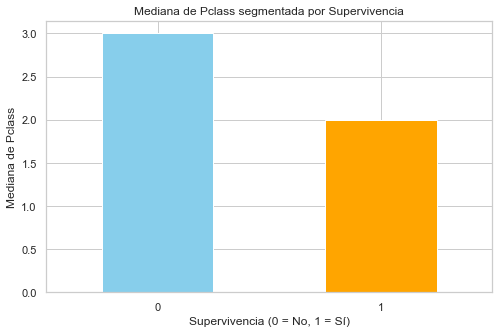

In [7]:


# Eliminar filas con valores faltantes en Pclass o Survived
data = data.dropna(subset=['Pclass', 'Survived'])

# Calcular la mediana de Pclass para cada categoría de Survived
mediana_general = data['Pclass'].median()
mediana_segmentada = data.groupby('Survived')['Pclass'].median()

# Resultados
print(f"Mediana general de Pclass: {mediana_general}")
print("Mediana de Pclass segmentada por Survived:")
print(mediana_segmentada)

# Visualización
import matplotlib.pyplot as plt

mediana_segmentada.plot(kind='bar', color=['skyblue', 'orange'], figsize=(8, 5))
plt.title('Mediana de Pclass segmentada por Supervivencia')
plt.xlabel('Supervivencia (0 = No, 1 = Sí)')
plt.ylabel('Mediana de Pclass')
plt.xticks(rotation=0)
plt.show()


***Medidas de tendencia central robustas***

***Outliers***
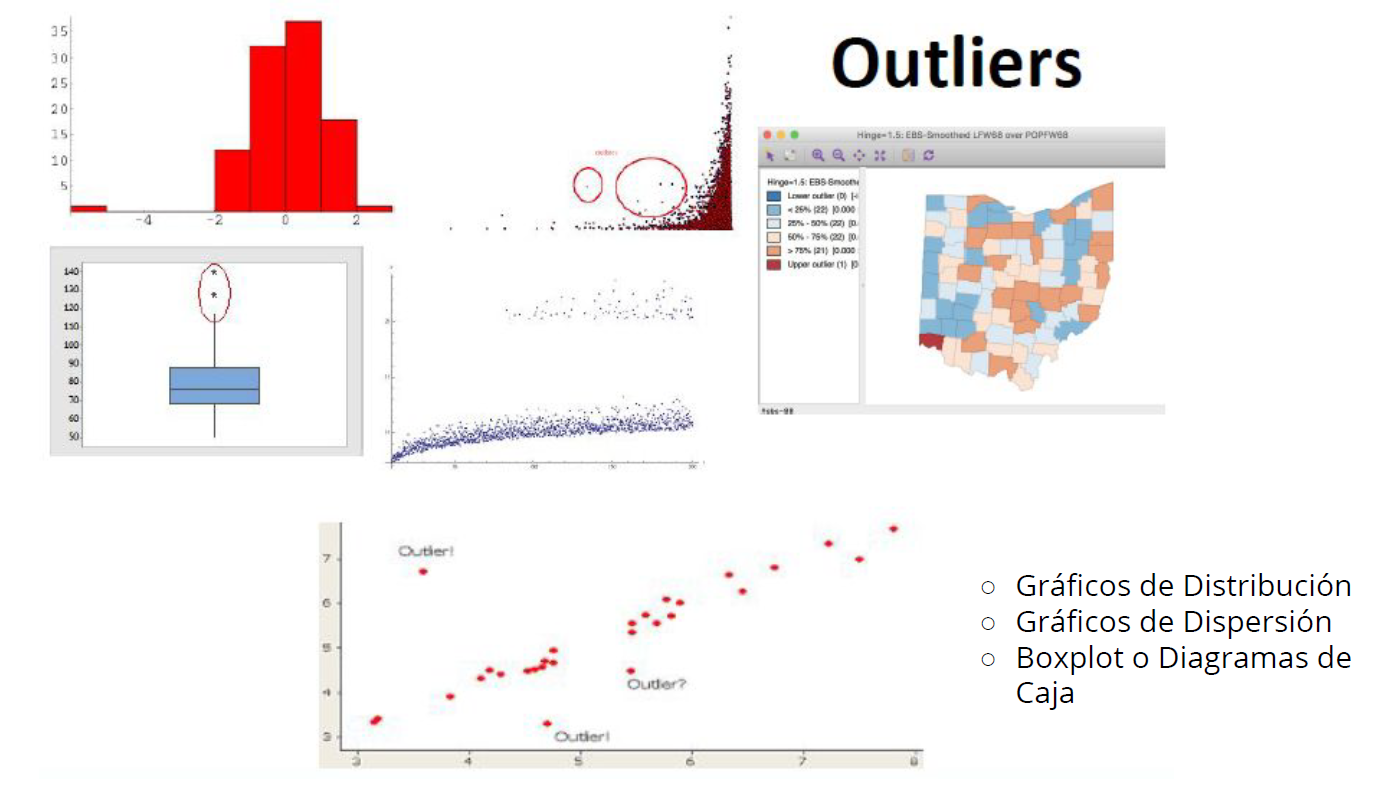
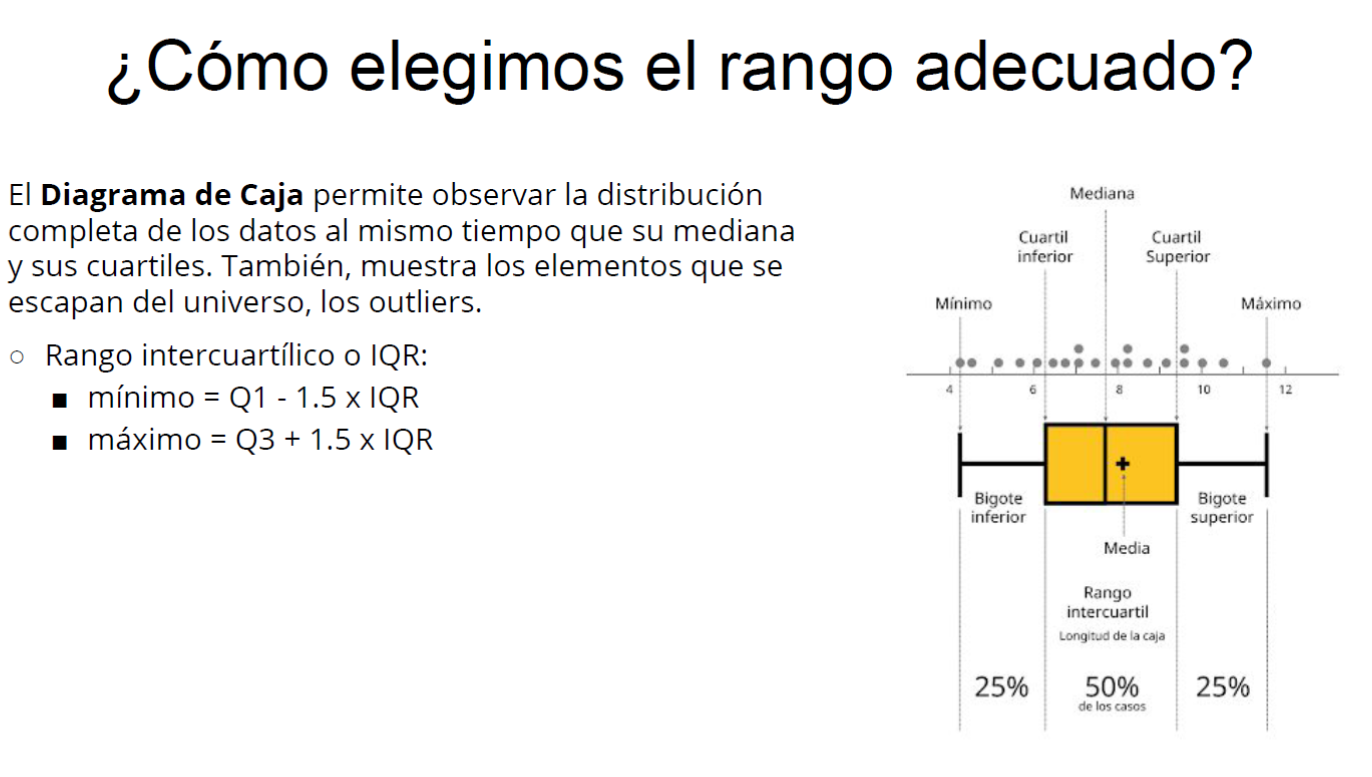
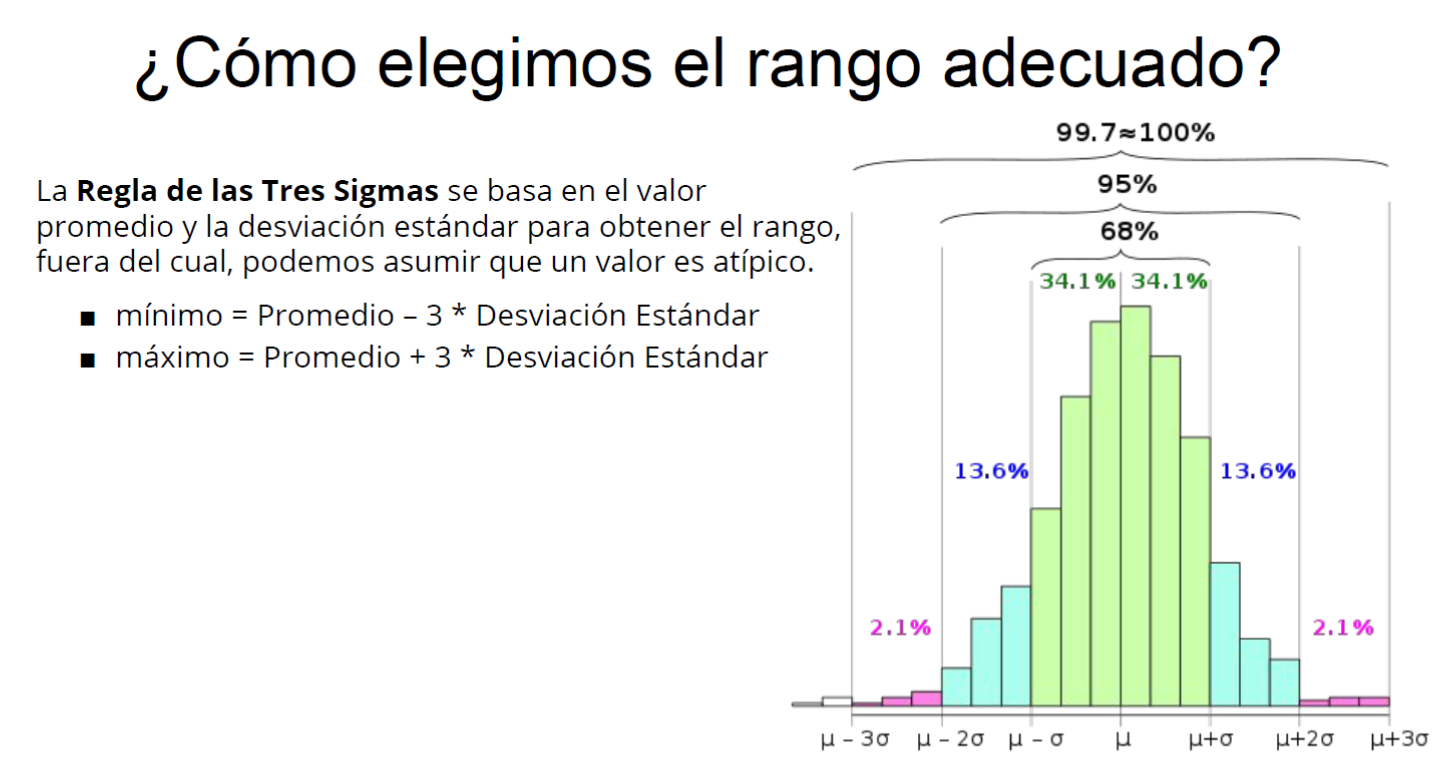


La media recortada y la media winsorizada son variantes de la media aritmética que ayudan a reducir el impacto de valores atípicos.

**Media Recortada**

    Se calcula eliminando un porcentaje de los valores más extremos (superiores e inferiores) del conjunto de datos antes de calcular la media.
    Por ejemplo, en una media recortada al 10%, eliminamos el 10% de los valores más bajos y el 10% de los más altos.
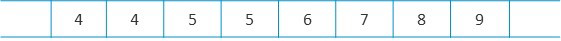

**Media Winsorizada**

    Similar a la media recortada, pero en lugar de eliminar los valores extremos, estos se reemplazan por los valores más cercanos dentro del rango permitido.
    Es útil para mitigar la influencia de los valores extremos sin eliminarlos completamente.
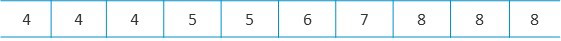

Media aritmética: 32.20
Media recortada (10%): 21.38
Media winsorizada (10%): 25.65


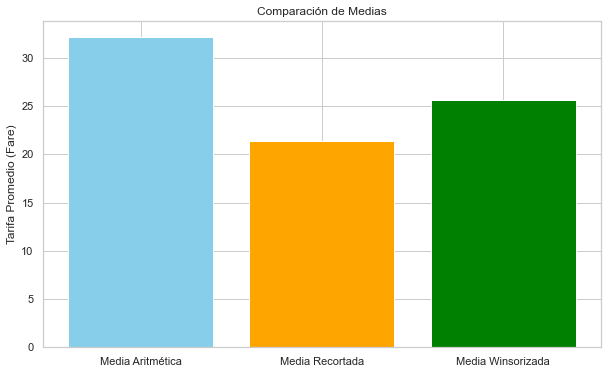

In [14]:
from scipy.stats import trim_mean

# Selección de la variable numérica (Fare)
variable = 'Fare'

# Eliminar valores NaN
data = data.dropna(subset=[variable])

# Media recortada (10%)
recorte = 0.1  # 10% de recorte
media_recortada = trim_mean(data[variable], proportiontocut=recorte)

# Media winsorizada (10%)
from scipy.stats import mstats

data_winsorizada = mstats.winsorize(data[variable], limits=(recorte, recorte))
media_winsorizada = data_winsorizada.mean()

# Resultados
media_aritmetica = data[variable].mean()
print(f"Media aritmética: {media_aritmetica:.2f}")
print(f"Media recortada (10%): {media_recortada:.2f}")
print(f"Media winsorizada (10%): {media_winsorizada:.2f}")

# Visualización
import matplotlib.pyplot as plt

medias = [media_aritmetica, media_recortada, media_winsorizada]
nombres = ['Media Aritmética', 'Media Recortada', 'Media Winsorizada']

plt.figure(figsize=(10, 6))
plt.bar(nombres, medias, color=['skyblue', 'orange', 'green'])
plt.title('Comparación de Medias')
plt.ylabel('Tarifa Promedio (Fare)')
plt.show()



--- 4. Detección de Valores Atípicos ---

Variable: Age
Valores atípicos detectados: 8
Límite inferior: -7.0, Límite superior: 65.0


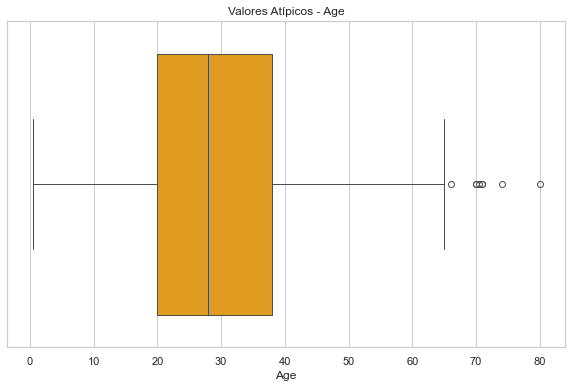


Variable: Fare
Valores atípicos detectados: 116
Límite inferior: -27.099999999999998, Límite superior: 66.3


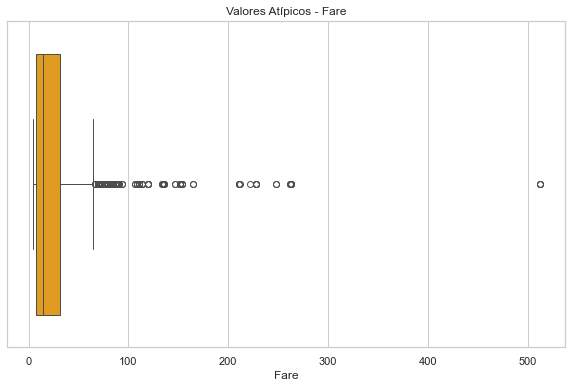

In [10]:
# --- 4. Detección de Valores Atípicos ---
print("\n--- 4. Detección de Valores Atípicos ---")
for var in variables:
    Q1 = data[var].quantile(0.25)
    Q3 = data[var].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[var] < lower_bound) | (data[var] > upper_bound)]
    print(f"\nVariable: {var}")
    print(f"Valores atípicos detectados: {len(outliers)}")
    print(f"Límite inferior: {lower_bound}, Límite superior: {upper_bound}")

    # Visualización
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=data[var], color='orange')
    plt.title(f"Valores Atípicos - {var}")
    plt.xlabel(var)
    plt.show()

Media: 32.20
Desviación estándar: 49.69
Límite inferior: -116.88
Límite superior: 181.28
Total de outliers: 20

Ejemplo de valores atípicos detectados:
         Fare
27   263.0000
88   263.0000
118  247.5208
258  512.3292
299  247.5208


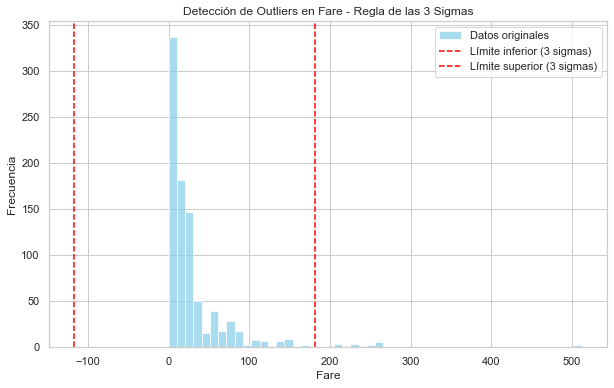

In [11]:
# Selección de la variable numérica Fare
variable = 'Fare'

# Calcular la media y la desviación estándar
media = data[variable].mean()
desviacion_std = data[variable].std()

# Calcular los límites usando la regla de las 3 sigmas
limite_inferior = media - 3 * desviacion_std
limite_superior = media + 3 * desviacion_std

# Filtrar los outliers
outliers = data[(data[variable] < limite_inferior) | (data[variable] > limite_superior)]
outliers_total = len(outliers)

# Resultados
print(f"Media: {media:.2f}")
print(f"Desviación estándar: {desviacion_std:.2f}")
print(f"Límite inferior: {limite_inferior:.2f}")
print(f"Límite superior: {limite_superior:.2f}")
print(f"Total de outliers: {outliers_total}")

# Mostrar algunos outliers
print("\nEjemplo de valores atípicos detectados:")
print(outliers[[variable]].head())

# Visualización de los outliers
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(data[variable], bins=50, color='skyblue', alpha=0.7, label='Datos originales')
plt.axvline(limite_inferior, color='red', linestyle='--', label='Límite inferior (3 sigmas)')
plt.axvline(limite_superior, color='red', linestyle='--', label='Límite superior (3 sigmas)')
plt.title(f"Detección de Outliers en {variable} - Regla de las 3 Sigmas")
plt.xlabel(variable)
plt.ylabel("Frecuencia")
plt.legend()
plt.show()


##### Medidas de dispersión

Las medidas de dispersión nos indican cuánto se desvían los datos, aspecto que es fundamental para conocer cómo se distribuye el conjunto de datos.

**Rango**
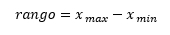

**varianza**
Es un promedio de las desviaciones de los datos a su media. Estas desviaciones son elevadas al cuadrado para que no le afecte el sentido de estas (si es negativo o positivo).


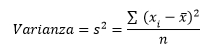


**Concepto de Cuasivarianza**

La cuasivarianza es una medida de dispersión similar a la varianza, pero se utiliza para conjuntos de datos muestrales en lugar de poblacionales. La principal diferencia es que la cuasivarianza ajusta el denominador, dividiendo por N−1N−1 en lugar de NN, para corregir el sesgo en la estimación de la varianza poblacional a partir de una muestra.
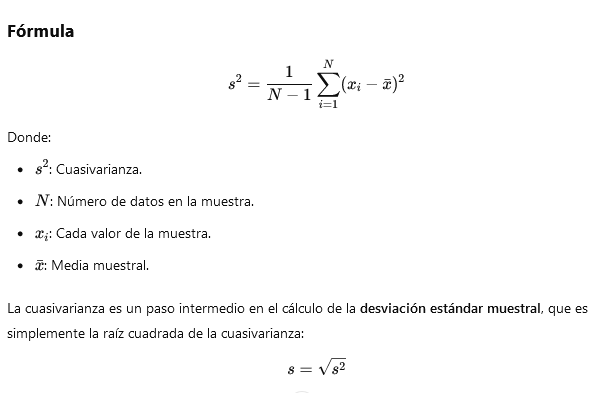

La **desviación estándar** es una medida de dispersión que indica cuánto varían los datos respecto a su media. Cuanto mayor sea la desviación estándar, más dispersos están los datos; cuanto menor sea, más concentrados están cerca de la media.

Matemáticamente, la desviación estándar se calcula como la raíz cuadrada de la varianza, que es el promedio de las diferencias al cuadrado entre cada valor y la media.

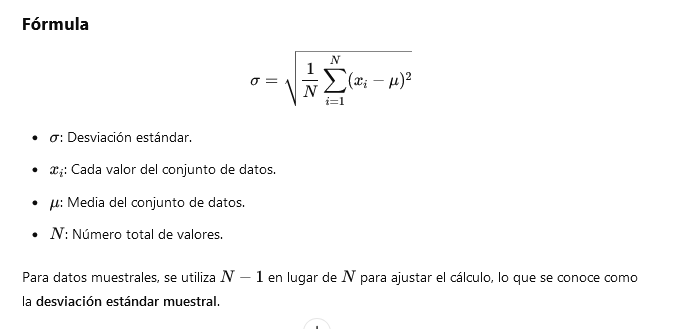

##### Medidas de dispersión robustas

**varianza winsorizada** 
siguiendo la siguiente fórmula:
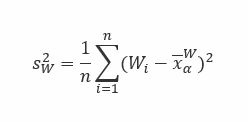

Donde Wi hace referencia al conjunto de datos winsorizado

**cuasivarianza winsorizada:**

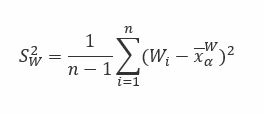
Donde la única diferencia con la fórmula anterior es que se divide entre en
vez de entre . Es importante tener en cuenta que es posible, tal y como sucedía con la desviación típica y la varianza, que puede calcularse la cuasidesviación típica winsorizada como la raíz de la cuasivarianza winsorizada

In [17]:
# --- 2. Medidas de Dispersión ---
# Seleccionar la variable numérica
import math
variable = 'Age'

# Eliminar valores NaN
data = data.dropna(subset=[variable])
values = data[variable]

# 1. Calcular la media
media = sum(values) / len(values)

# 2. Varianza (dividido por N)
varianza = sum((x - media) ** 2 for x in values) / len(values)

# 3. Cuasivarianza (dividido por N-1)
n = len(values)
cuasivarianza = sum((x - media) ** 2 for x in values) / (n - 1)

# 4. Desviación estándar (raíz cuadrada de la cuasivarianza)
desviacion_estandar = math.sqrt(cuasivarianza)

# 5. Varianza Winsorizada
recorte = 0.1  # Recorte del 10% en ambos extremos
winsorizados = mstats.winsorize(values, limits=(recorte, recorte))
media_winsorizada = sum(winsorizados) / len(winsorizados)
varianza_winsorizada = sum((x - media_winsorizada) ** 2 for x in winsorizados) / len(winsorizados)

# 6. Cuasivarianza Winsorizada
cuasivarianza_winsorizada = sum((x - media_winsorizada) ** 2 for x in winsorizados) / (n - 1)

# 7. Coeficiente de variación (desviación estándar relativa)
coeficiente_variacion = (desviacion_estandar / media) * 100  # En porcentaje

# Mostrar resultados
print(f"Media: {media:.2f}")
print(f"Varianza: {varianza:.2f}")
print(f"Cuasivarianza: {cuasivarianza:.2f}")
print(f"Desviación Estándar: {desviacion_estandar:.2f}")
print(f"Varianza Winsorizada: {varianza_winsorizada:.2f}")
print(f"Cuasivarianza Winsorizada: {cuasivarianza_winsorizada:.2f}")
print(f"Coeficiente de Variación: {coeficiente_variacion:.2f}%")


Media: 29.70
Varianza: 210.72
Cuasivarianza: 211.02
Desviación Estándar: 14.53
Varianza Winsorizada: 130.98
Cuasivarianza Winsorizada: 131.17
Coeficiente de Variación: 48.91%


##### Medidas de posición y forma
Las medidas de posición son necesarias para poder saber si un valor está alejado o no de su media, lo cual nos da idea de lo extremo que es comparado con la «mayoría» de los datos de su conjunto.

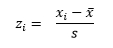
Los valores zi son llamados puntuaciones tipificadas y nos indican el número de desviaciones típicas que se aleja un valor de su media


Media: 34.69
Desviación Estándar: 52.92

Ejemplo de valores tipificados (Z):
      Fare    Z_Fare
0   7.2500 -0.518614
1  71.2833  0.691412
2   7.9250 -0.505859
3  53.1000  0.347805
4   8.0500 -0.503497

Media de los valores Z: -0.00 (debería ser 0)
Desviación estándar de los valores Z: 1.00 (debería ser 1)


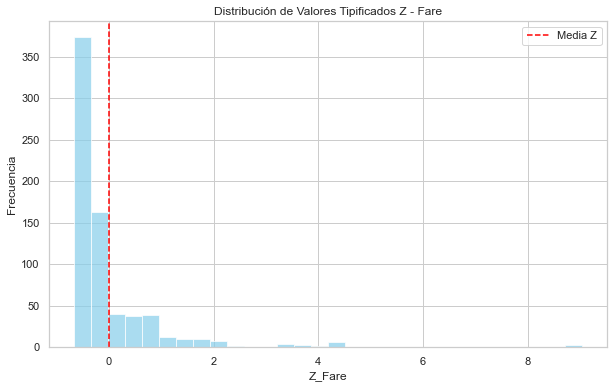

In [18]:
# Seleccionar la variable (Fare)
variable = 'Fare'

# Eliminar valores NaN
data = data.dropna(subset=[variable])

# Calcular media y desviación estándar
media = data[variable].mean()
desviacion_estandar = data[variable].std()

# Calcular valores Z (tipificados)
data['Z_Fare'] = (data[variable] - media) / desviacion_estandar

# Mostrar resultados
print(f"Media: {media:.2f}")
print(f"Desviación Estándar: {desviacion_estandar:.2f}")
print("\nEjemplo de valores tipificados (Z):")
print(data[['Fare', 'Z_Fare']].head())

# Verificar propiedades
z_media = data['Z_Fare'].mean()
z_desviacion = data['Z_Fare'].std()

print(f"\nMedia de los valores Z: {z_media:.2f} (debería ser 0)")
print(f"Desviación estándar de los valores Z: {z_desviacion:.2f} (debería ser 1)")

# Visualización de los valores Z
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(data['Z_Fare'], bins=30, color='skyblue', alpha=0.7)
plt.title('Distribución de Valores Tipificados Z - Fare')
plt.xlabel('Z_Fare')
plt.ylabel('Frecuencia')
plt.axvline(0, color='red', linestyle='--', label='Media Z')
plt.legend()
plt.show()


**Valores positivos:**

    Indican que están por encima de la media.

**Valores negativos:**

    Indican que están por debajo de la media.

**Valores extremos:**

    Valores mayores a +3 o menores a −3 son considerados atípicos en una distribución normal estándar.

***Asimetria y apuntamiento***

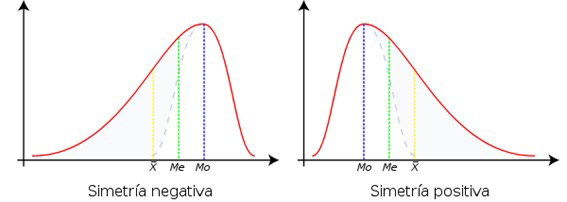
Para medir la simetría los programas
estadísticos en ocasiones también confeccionan un coeficiente de simetría ( de Pearson) que resulta positivo cuando la asimetría es positiva resultando que la media sea mayor que la moda, nulo cuando es simétrica (Moda=Media) y negativo cuando la asimetría es negativa resultando que la moda sea mayor que media.
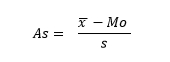

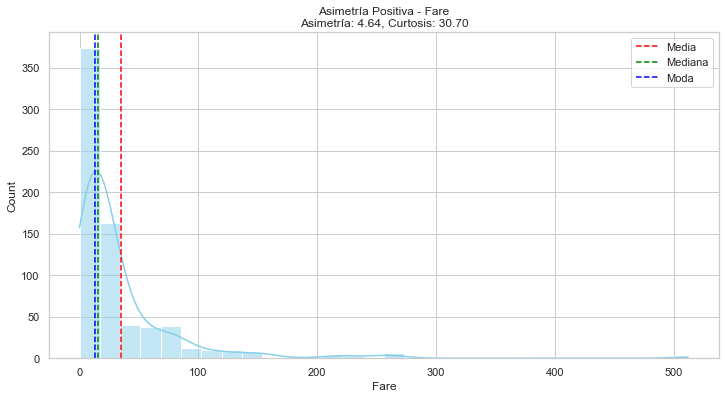

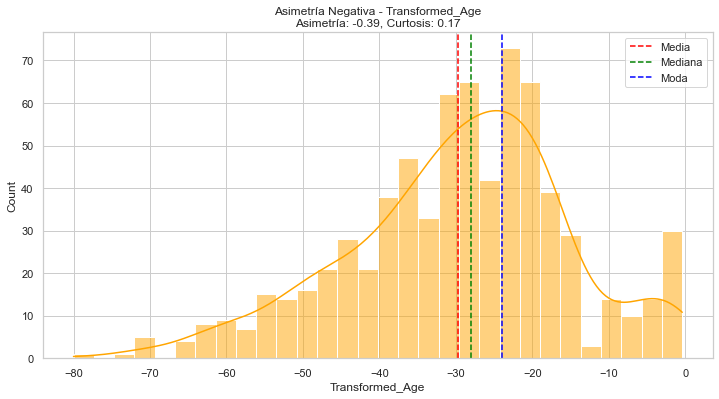

In [19]:
# --- 3. Medidas de Posición y Forma ---
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis

# Filtrar datos válidos
data = data.dropna(subset=['Fare', 'Age'])

# Crear una transformación negativa para la variable Age (ejemplo de asimetría negativa)
data['Transformed_Age'] = -data['Age']

# Calcular medidas para Fare (asimetría positiva)
fare_skew = skew(data['Fare'])
fare_kurtosis = kurtosis(data['Fare'])
fare_mean = data['Fare'].mean()
fare_median = data['Fare'].median()
fare_mode = data['Fare'].mode()[0]

# Calcular medidas para Transformed_Age (asimetría negativa)
age_skew = skew(data['Transformed_Age'])
age_kurtosis = kurtosis(data['Transformed_Age'])
age_mean = data['Transformed_Age'].mean()
age_median = data['Transformed_Age'].median()
age_mode = data['Transformed_Age'].mode()[0]

# --- Graficar distribuciones ---
# Distribución de Fare (asimetría positiva)
plt.figure(figsize=(12, 6))
sns.histplot(data['Fare'], kde=True, color='skyblue', bins=30)
plt.axvline(fare_mean, color='red', linestyle='--', label='Media')
plt.axvline(fare_median, color='green', linestyle='--', label='Mediana')
plt.axvline(fare_mode, color='blue', linestyle='--', label='Moda')
plt.title(f"Asimetría Positiva - Fare\nAsimetría: {fare_skew:.2f}, Curtosis: {fare_kurtosis:.2f}")
plt.legend()
plt.show()

# Distribución de Transformed_Age (asimetría negativa)
plt.figure(figsize=(12, 6))
sns.histplot(data['Transformed_Age'], kde=True, color='orange', bins=30)
plt.axvline(age_mean, color='red', linestyle='--', label='Media')
plt.axvline(age_median, color='green', linestyle='--', label='Mediana')
plt.axvline(age_mode, color='blue', linestyle='--', label='Moda')
plt.title(f"Asimetría Negativa - Transformed_Age\nAsimetría: {age_skew:.2f}, Curtosis: {age_kurtosis:.2f}")
plt.legend()
plt.show()


***Cuartiles, percentiles y cuantiles***

Q1=P25
Q2=P50=Me
Q3=P75



Estadísticos Resumidos:
          Media      Q1  Mediana      Q3     IQR  Mínimo    Máximo  \
Fare  34.694514   8.050  15.7417  33.375  25.325    0.00  512.3292   
Age   29.699118  20.125  28.0000  38.000  17.875    0.42   80.0000   

      Límite Inferior  Límite Superior  Outliers  
Fare         -29.9375          71.3625      94.0  
Age           -6.6875          64.8125      11.0  


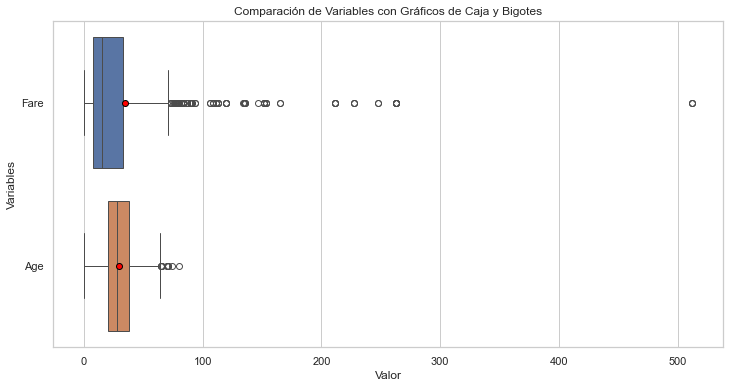

In [20]:


# Filtrar variables numéricas de interés
variables = ['Fare', 'Age']
data = data.dropna(subset=variables)

# Crear un DataFrame con estadísticos clave
stats = {}
for var in variables:
    q1 = data[var].quantile(0.25)
    q2 = data[var].median()
    q3 = data[var].quantile(0.75)
    iqr = q3 - q1  # Rango intercuartílico
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = data[(data[var] < lower_bound) | (data[var] > upper_bound)]
    stats[var] = {
        'Media': data[var].mean(),
        'Q1': q1,
        'Mediana': q2,
        'Q3': q3,
        'IQR': iqr,
        'Mínimo': data[var].min(),
        'Máximo': data[var].max(),
        'Límite Inferior': lower_bound,
        'Límite Superior': upper_bound,
        'Outliers': len(outliers),
    }

stats_df = pd.DataFrame(stats).T
print("Estadísticos Resumidos:")
print(stats_df)

# Crear gráficos de caja y bigotes
plt.figure(figsize=(12, 6))
sns.boxplot(data=data[variables], orient='h', showmeans=True, meanprops={"marker": "o", "markerfacecolor": "red", "markeredgecolor": "black"})
plt.title("Comparación de Variables con Gráficos de Caja y Bigotes")
plt.xlabel("Valor")
plt.ylabel("Variables")
plt.show()


Distribución de Fare:

    Valores extremos altos indican pasajeros que pagaron tarifas significativamente mayores.
    Asimetría positiva, con varios outliers más allá del límite superior.

Distribución de Age:

    Rango intercuartílico más compacto.
    Pocos outliers, indicando que la mayoría de las edades están dentro de los límites.

Comparación:

    El Fare tiene mayor variabilidad y outliers en comparación con Age.